In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [2]:
img_size = (160,160)     # reduced from 224
batch_size = 8           # reduced from 16

In [3]:
from tensorflow.keras.applications.resnet50 import preprocess_input
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    zoom_range=0.25,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_data = train_gen.flow_from_directory(
    "../data/train",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=True
)

val_data = val_gen.flow_from_directory(
    "../data/val",
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

Found 10500 images belonging to 10 classes.
Found 3501 images belonging to 10 classes.


In [4]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(160,160,3)
)

base_model.trainable = False

In [5]:
print(train_data.samples)
print(val_data.samples)
print(train_data.class_indices)

10500
3501
{'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8, 'Unknown': 9}


In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(train_data.num_classes, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    callbacks=[early_stop]
)

Epoch 1/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 555s 416ms/step - accuracy: 0.6985 - loss: 0.8803 - val_accuracy: 0.7715 - val_loss: 0.7180
Epoch 2/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 329s 251ms/step - accuracy: 0.7807 - loss: 0.6250 - val_accuracy: 0.7772 - val_loss: 0.6636
Epoch 3/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 294s 224ms/step - accuracy: 0.8043 - loss: 0.5481 - val_accuracy: 0.7772 - val_loss: 0.6573
Epoch 4/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 363s 276ms/step - accuracy: 0.8249 - loss: 0.4996 - val_accuracy: 0.7855 - val_loss: 0.6266
Epoch 5/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 301s 229ms/step - accuracy: 0.8360 - loss: 0.4599 - val_accuracy: 0.7935 - val_loss: 0.6486
Epoch 6/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 260s 198ms/step - accuracy: 0.8411 - loss: 0.4374 - val_accuracy: 0.7741 - val_loss: 0.7486
Epoch 7/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 260s 198ms/step - accuracy: 0.8516 - loss: 0.4135 - val_accuracy: 0.7941 - val_loss: 0.6332
Epoch 8/15
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 261s 199ms/step - ac

KeyboardInterrupt: 

In [10]:
model.save("../models/resnet50_weed.keras")
print("Model saved ")

Model saved 


FINETUNING

In [11]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3484s 3s/step - accuracy: 0.6708 - loss: 1.0835 - val_accuracy: 0.7178 - val_loss: 1.0790
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1742s 1s/step - accuracy: 0.7549 - loss: 0.7138 - val_accuracy: 0.7669 - val_loss: 0.7710
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 811s 618ms/step - accuracy: 0.7986 - loss: 0.5909 - val_accuracy: 0.7869 - val_loss: 0.6923
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 1149s 874ms/step - accuracy: 0.8197 - loss: 0.5172 - val_accuracy: 0.8143 - val_loss: 0.5760
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 890s 666ms/step - accuracy: 0.8436 - loss: 0.4484 - val_accuracy: 0.8309 - val_loss: 0.5486


In [12]:
# freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

for layer in base_model.layers[-30:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_fine2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 348s 260ms/step - accuracy: 0.8770 - loss: 0.3603 - val_accuracy: 0.8418 - val_loss: 0.5031
Epoch 2/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 385s 293ms/step - accuracy: 0.8936 - loss: 0.3057 - val_accuracy: 0.8438 - val_loss: 0.5096
Epoch 3/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 394s 300ms/step - accuracy: 0.9051 - loss: 0.2772 - val_accuracy: 0.8512 - val_loss: 0.5026
Epoch 4/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 342s 261ms/step - accuracy: 0.9126 - loss: 0.2621 - val_accuracy: 0.8626 - val_loss: 0.4761
Epoch 5/5
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 391s 298ms/step - accuracy: 0.9218 - loss: 0.2291 - val_accuracy: 0.8626 - val_loss: 0.4938


In [12]:


for layer in base_model.layers[-40:]:
    layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
early = EarlyStopping(
    monitor="val_accuracy",
    patience=2,
    restore_best_weights=True
)

history_extra = model.fit(
    train_data,
    validation_data=val_data,
    epochs=3,
    callbacks=[early]
)

Epoch 1/3
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 502s 374ms/step - accuracy: 0.5694 - loss: 1.3159 - val_accuracy: 0.6875 - val_loss: 0.9483
Epoch 2/3
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 536s 409ms/step - accuracy: 0.6864 - loss: 0.9039 - val_accuracy: 0.7309 - val_loss: 0.8146
Epoch 3/3
  23/1313 ━━━━━━━━━━━━━━━━━━━━ 10:39 496ms/step - accuracy: 0.7191 - loss: 0.8493

KeyboardInterrupt: 

In [2]:
model.save("../models/resnet50_final.keras")
print("Final model saved")

NameError: name 'model' is not defined

In [18]:
import pickle

with open("../results/history.pkl", "wb") as f:
    pickle.dump(history_fine.history, f)

print("History saved")

History saved


In [8]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="../results/model_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=300
)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.


In [7]:
!pip install pydot graphviz

In [10]:
import graphviz

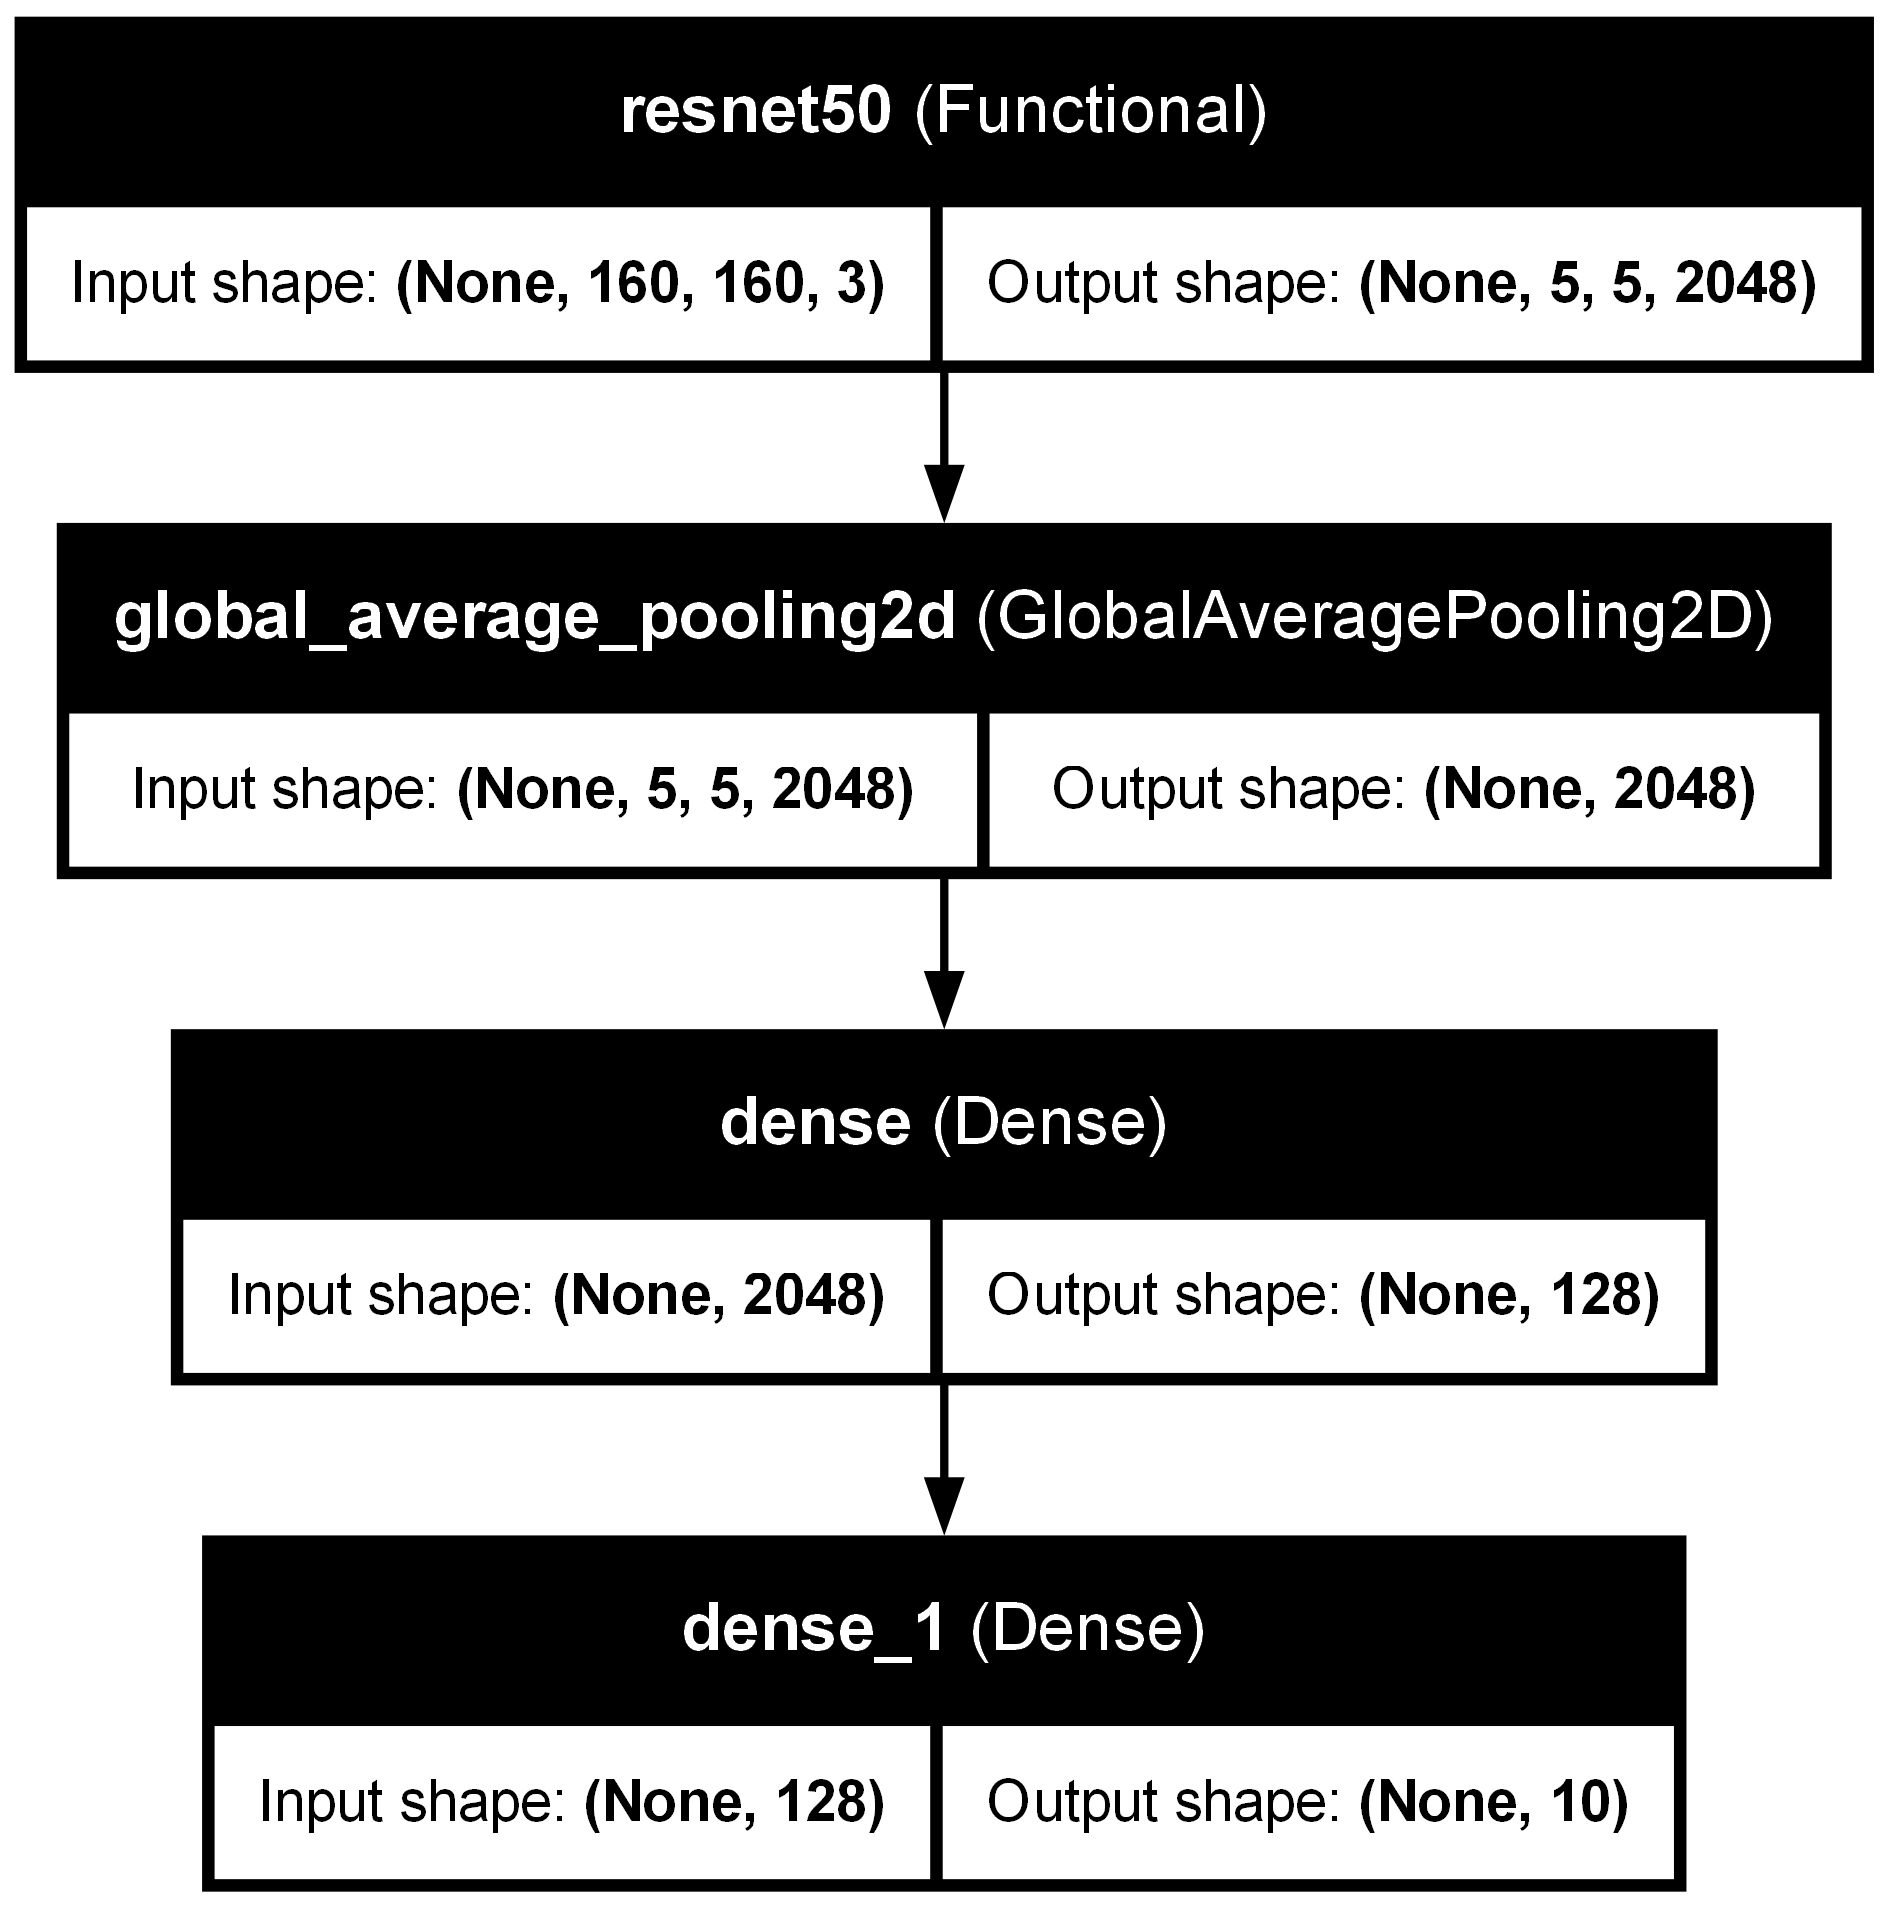

In [8]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="../results/model_architecture.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=300
)